In [1]:
### Preamples ###
import numpy as np
import matplotlib.pyplot as plt
import random
from numba import njit

random.seed(13)

In [2]:
@njit
def heston_returns(V0, N, mu, theta, kappa, sigma_V, rho, h, n_sub):
    
    dt = h / n_sub
    sqrt_dt = dt ** 0.5
    c = (1 - rho ** 2) ** 0.5 
    
    returns = np.empty(N)
  
    Vt = V0
    log_ret = 0
    
    for n in range(N):
        log_ret = 0
        for _ in range(n_sub):
            z1 = np.random.normal(0, 1)
            z2 = np.random.normal(0, 1)
            
            dB1 = sqrt_dt * z1
            dB2 = sqrt_dt * (rho * z1 + c * z2) 
            
            Vt_pos = Vt if Vt > 0 else 0 # ensure variance is non-negative for the price update
            
            log_ret += (mu - 0.5 * Vt) * dt + Vt_pos ** 0.5 * dB1 # log return increment
            
            Vt = Vt_pos + kappa * (theta - Vt_pos)* dt + sigma_V * Vt_pos ** 0.5 * dB2  # variance process
            
        returns[n] = log_ret
        
    return returns 

In [3]:
def h_tilde(kappa, h):
    "h_tidle = (1 - exp(-kappa * h)) / kappa"
    return (1 - np.exp(-kappa * h)) / kappa

def lagm_cov_est(ret, m):
    
    N = len(ret)
    Ybar = np.mean(ret)
    
    cov = np.sum((ret[:N-m] - Ybar) * (ret[m:] - Ybar)) / (N - m)
    return cov

def estimate_kappa(ret, h , lag_M = 10):
    N = len(ret)
    
    lag1 = lagm_cov_est(ret, 1)
    
    kappa_sum = 0
    
    for m in range(2, lag_M + 1):
        lagm = lagm_cov_est(ret, m)
        
        if lagm == 0 or np.sign(lag1) != np.sign(lagm):
            continue
        
        ratio = lag1 / lagm
        if ratio <= 0 or not np.isfinite(np.log(ratio)):
            continue
        
        k_est = np.log(ratio) / ((m-1) * h)
        if not np.isfinite(k_est) or k_est <= 0:
            continue
        kappa_sum += k_est
        
    kappa = kappa_sum / (lag_M - 1)
    return kappa

def estimate_moments(ret):
    n = len(ret)
    Ybar = np.mean(ret)
    mean = Ybar
    var = np.var(ret, ddof = 1)
    lag1 = lagm_cov_est(ret, 1) 
    lag2 = lagm_cov_est(ret, 2)

    y2 = ret[:-1]**2
    y2d = y2 - np.mean(y2)
    yn1d = ret[1:] - np.mean(ret[1:])
    cross = np.mean(y2d * yn1d)
    
    return np.array([mean, var, lag1, lag2, cross])

def moments(mu, theta, kappa, sigma_V, rho, h):
    """Returns first five moments of the log returns of the Heston model."""
    ht = h_tilde(kappa, h)
    ek = np.exp(-kappa * h)
    
    # First moment (mean), follows from Theorem 2.1
    
    mean = h * (mu  - 0.5 * theta)
    
    # Second moment (variance), follows from Theorem 2.2
    
    var = theta * (h - ht) * ( (sigma_V**2)/ (4 * (kappa ** 2)) 
                              - (rho * sigma_V) / kappa) + theta * h
    
    # Third moment (lag-1 autocovariance), follows from Theorem 2.3
    
    lag1 = (((ht ** 2) * theta * (sigma_V)) / 2 ) * ( (sigma_V) / (4 * kappa) - rho)
    
    # Fourth moment (lag-2 autocovariance), follows from Theorem 2.4
    
    lag2 = ek * lag1
    
    
    # Fifth moment (Cross variance bewteen squared retursn and future returns),
    # follows from Theorem 2.5
    
    term1 = ((theta * (sigma_V ** 4) / ( 8 * kappa **3))) * ht * (h * ek - ht)
    
    term2 = ht**2 * ((theta * sigma_V ** 2) / (4 * kappa) * mu * h
                     - (theta ** 2 * sigma_V ** 2) / (8 * kappa) * h
                     - (theta * sigma_V ** 2 ) / (4 * kappa))
    
    term3  = (-rho * sigma_V / 2 * ht) * (
        (3 * sigma_V**2 / (2 * kappa**2) - 2 * rho * sigma_V / kappa)
        * theta * (h * ek - ht)
        + (2 * mu * theta - theta**2) * h * ht
)
    
    cross = term1 + term2 - term3
    
    return mean, var, lag1, lag2, cross

In [4]:
def estimate_heston_from_returns(ret, h, verbose= False):
    N = len(ret)
    mean_e, var_e, lag1_e, lag2_e, cross_e = estimate_moments(ret)
    
    kappa = estimate_kappa(ret, h)
    
    ht = h_tilde(kappa, h)
    
    ek = np.exp(-kappa * h)
    
    dh = h * ek - ht
    
    theta = var_e / h  - (2* (h-ht) / (h * kappa * ht ** 2)) * lag1_e 
    
    mu = mean_e / h + theta / 2
    
    num   = (4*kappa*mean_e
             + (8*dh/(theta*ht**3))*lag1_e
             - 2*kappa*cross_e/lag1_e)
    den   = (theta*ht**2/(2*lag1_e) - dh/(kappa*ht))

    sigma_sq = num / den
    sigma_V = sigma_sq**0.5
    
    rho = np.clip(sigma_V/(4*kappa) - (2/(theta*sigma_V*ht**2))*lag1_e,
                  -0.999, 0.999)
    
    if verbose:
        print( f"  κ̂    = {kappa:.4f}")
        print(f"  θ̂    = {theta:.4f}")
        print(f"  μ̂    = {mu:.4f}")
        print(f"  σ̂_V  = {sigma_V:.6f}")
        print(f"  ρ̂    = {rho:.6f}")
    

    return {'mu': mu, 'theta': theta, 'kappa': kappa,
            'sigma_V': sigma_V, 'rho': rho}
    

In [9]:
def experiment_rho_sweep(TRUE_base, V0, h, n_sub, n_rep=100, N=int(400_000)):
    """
    Sweeps rho from -0.9 to 0.9.
    Shows how leverage effect affects estimation of all parameters.
    Key finding: more negative rho → better identification of sigma_V
    through cross-covariance moment.
    """
    rho_vals = [-0.9, -0.7, -0.5, -0.3, 0.0, 0.3, 0.5, 0.7, 0.9]

    results = []
    for rho in rho_vals:
        TRUE  = {**TRUE_base, 'rho': rho}
        stds  = {k: [] for k in ['kappa', 'sigma_V', 'rho']}
        failed = 0

        for r in range(n_rep):
            ret = heston_returns(V0, N,
                                 TRUE['mu'], TRUE['theta'], TRUE['kappa'],
                                 TRUE['sigma_V'], rho, h, n_sub)
            try:
                est = estimate_heston_from_returns(ret, h)
                for k in ['kappa', 'sigma_V', 'rho']:
                    val = est[k]
                    if np.isfinite(val):
                        stds[k].append(est[k])
            except Exception:
                failed += 1

        results.append({
            'rho'       : rho,
            'std_kappa' : np.std(stds['kappa']) if len(stds['kappa']) > 1 else np.nan,
            'std_sigmaV': np.std(stds['sigma_V']) if len(stds['kappa']) > 1 else np.nan,
            'std_rho'   : np.std(stds['rho']) if len(stds['kappa']) > 1 else np.nan,
            'failed'    : failed
        })

    print(f"\n{'ρ':>6s}  {'std(κ)':>10s}  {'std(σ_V)':>10s}  "
          f"{'std(ρ)':>10s}  {'Failed':>8s}")
    print("-" * 52)
    for r in results:
        print(f"  {r['rho']:>4.1f}  {r['std_kappa']:>10.4f}  "
              f"{r['std_sigmaV']:>10.4f}  "
              f"{r['std_rho']:>10.4f}  {r['failed']:>8d}")

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle('Estimation precision vs correlation ρ', fontweight='bold')
    rho_plot = [r['rho'] for r in results]
    for ax, key, label in zip(axes,
                               ['std_kappa', 'std_sigmaV', 'std_rho'],
                               [r'std($\hat\kappa$)',
                                r'std($\hat\sigma_V$)',
                                r'std($\hat\rho$)']):
        vals = [r[key] for r in results]
        ax.plot(rho_plot, vals, 'o-', color='#1565C0', lw=2)
        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3, ls=':')
        ax.axvline(0, color='grey', lw=0.8, ls='--')
    plt.tight_layout()
    plt.show()
    return results

C:\Users\karis\AppData\Local\Temp\ipykernel_93232\2288375377.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return (1 - np.exp(-kappa * h)) / kappa



     ρ      std(κ)    std(σ_V)      std(ρ)    Failed
----------------------------------------------------
  -0.9      0.0106      0.0066      0.0427         0
  -0.7      0.0123      0.0079      0.0459         0
  -0.5      0.0176      0.0108      0.0382         0
  -0.3      0.0221      0.0132      0.0278         0
   0.0      0.0476      0.0256      0.0441         0
   0.3      0.1525      0.0678      0.1705         0
   0.5      0.0470      0.0261      0.0806         0
   0.7      0.0219      0.0122      0.0487         0
   0.9      0.0200      0.0118      0.0547         0


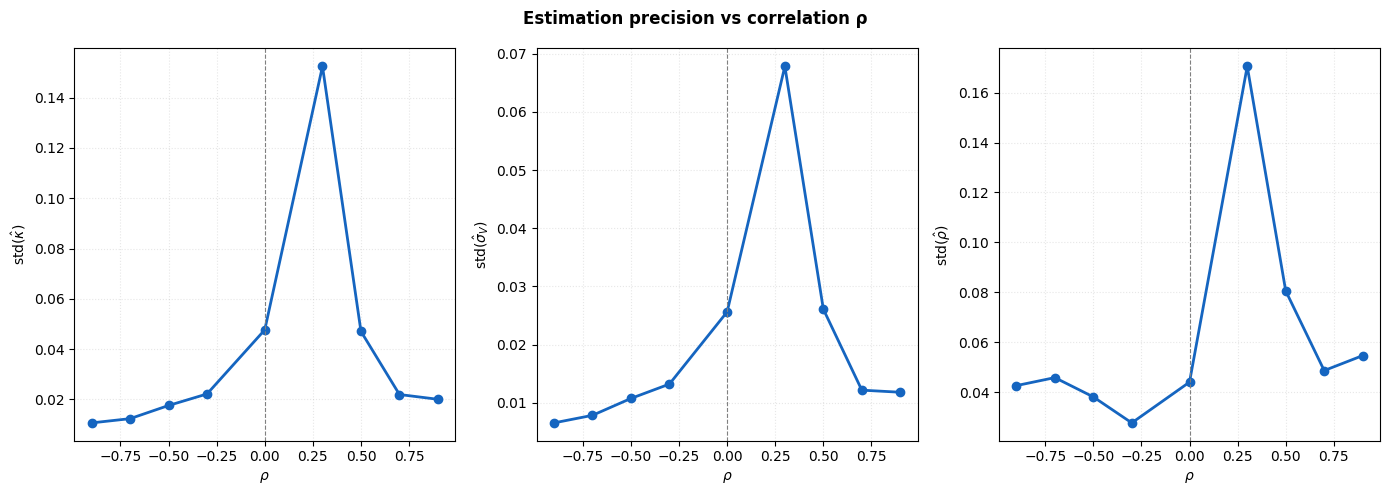

[{'rho': -0.9,
  'std_kappa': np.float64(0.01063044174699158),
  'std_sigmaV': np.float64(0.006564164286100514),
  'std_rho': np.float64(0.04268409225027734),
  'failed': 0},
 {'rho': -0.7,
  'std_kappa': np.float64(0.0123158918349594),
  'std_sigmaV': np.float64(0.007862752127899867),
  'std_rho': np.float64(0.04589100101945458),
  'failed': 0},
 {'rho': -0.5,
  'std_kappa': np.float64(0.017553761054255913),
  'std_sigmaV': np.float64(0.010765117644039396),
  'std_rho': np.float64(0.03817343711389036),
  'failed': 0},
 {'rho': -0.3,
  'std_kappa': np.float64(0.022142373565335792),
  'std_sigmaV': np.float64(0.01323080068555069),
  'std_rho': np.float64(0.02776403478659689),
  'failed': 0},
 {'rho': 0.0,
  'std_kappa': np.float64(0.04764597275998287),
  'std_sigmaV': np.float64(0.02563673694415018),
  'std_rho': np.float64(0.04407992406027366),
  'failed': 0},
 {'rho': 0.3,
  'std_kappa': np.float64(0.1524842899238616),
  'std_sigmaV': np.float64(0.06781378536402442),
  'std_rho': np.f

In [10]:
TRUE_base = dict(mu=0.125, kappa=0.1, theta=0.25, sigma_V=0.1, rho=-0.7)
V0 = TRUE_base['theta']    # start in stationarity
h = 1.0              # annual observation interval
N = int(400_000)          # number of observations
n_sub = int(20)              # sub-steps per interval — critical for stability

experiment_rho_sweep(TRUE_base, V0, h, n_sub, n_rep=50, N=int(400_000))

In [11]:
def experiment_rho_sweep_v2(TRUE_base, V0, h, n_sub, n_rep=100, N=int(400_000)):

    rho_vals  = [-0.9, -0.7, -0.5, -0.3, 0.0, 0.3, 0.5, 0.7, 0.9]
    keys      = ['kappa', 'sigma_V', 'rho']
    results   = []

    for rho in rho_vals:
        TRUE      = {**TRUE_base, 'rho': rho}
        estimates = {k: [] for k in keys}
        failed    = 0

        for r in range(n_rep):
            ret = heston_returns(V0, N,
                                 TRUE['mu'], TRUE['theta'], TRUE['kappa'],
                                 TRUE['sigma_V'], rho, h, n_sub)
            try:
                est = estimate_heston_from_returns(ret, h, verbose=False)
                for k in keys:
                    if np.isfinite(est[k]):
                        estimates[k].append(est[k])
            except Exception:
                failed += 1

        true_k = {'kappa'  : TRUE_base['kappa'],
                  'sigma_V': TRUE_base['sigma_V'],
                  'rho'    : rho}
        row = {'rho': rho, 'failed': failed,
               'n_valid': len(estimates['kappa'])}

        for k in keys:
            vals = np.array(estimates[k])
            if len(vals) > 1:
                row[f'mean_{k}'] = vals.mean()
                row[f'bias_{k}'] = vals.mean() - true_k[k]
                row[f'std_{k}']  = vals.std()
                row[f'rmse_{k}'] = np.sqrt((vals.mean()-true_k[k])**2
                                            + vals.var())
            else:
                for s in ['mean','bias','std','rmse']:
                    row[f'{s}_{k}'] = np.nan
        results.append(row)

    # ── Bias and std table ─────────────────────────────────────────────────
    print(f"\n{'ρ':>6s}  {'Valid':>6s}  " +
          "  ".join(f"{'bias('+k+')':>10s}  {'std('+k+')':>9s}"
                    for k in keys))
    print("-" * 80)
    for r in results:
        print(f"  {r['rho']:>4.1f}  {r['n_valid']:>6d}  " +
              "  ".join(
                  f"{r[f'bias_{k}']:>10.4f}  {r[f'std_{k}']:>9.4f}"
                  if np.isfinite(r[f'bias_{k}']) else
                  f"{'nan':>10s}  {'nan':>9s}"
                  for k in keys))

    # ── RMSE table ─────────────────────────────────────────────────────────
    print(f"\n{'ρ':>6s}  " +
          "  ".join(f"{'RMSE('+k+')':>10s}" for k in keys))
    print("-" * 44)
    for r in results:
        print(f"  {r['rho']:>4.1f}  " +
              "  ".join(
                  f"{r[f'rmse_{k}']:>10.4f}"
                  if np.isfinite(r[f'rmse_{k}']) else
                  f"{'nan':>10s}"
                  for k in keys))

    # ── Plot: bias and std side by side ────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle('ρ Sweep — Bias and Std of Key Parameters',
                 fontweight='bold')
    rho_plot = [r['rho'] for r in results]
    labels   = [r'$\hat\kappa$', r'$\hat\sigma_V$', r'$\hat\rho$']

    for col, (k, label) in enumerate(zip(keys, labels)):
        bias_vals = [r[f'bias_{k}'] for r in results]
        std_vals  = [r[f'std_{k}']  for r in results]

        # Top — bias
        ax = axes[0, col]
        ax.plot(rho_plot, bias_vals, 'o-', color='#1565C0', lw=2)
        ax.axhline(0, color='black', lw=0.8, ls=':')
        ax.axvline(0, color='grey',  lw=0.8, ls='--', alpha=0.5)
        ax.set_title(f'Bias — {label}', fontsize=11)
        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(f'bias({label})')
        ax.grid(True, alpha=0.3, ls=':')

        # Bottom — std
        ax = axes[1, col]
        ax.plot(rho_plot, std_vals, 's-', color='#C62828', lw=2)
        ax.axvline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
        ax.set_title(f'Std — {label}', fontsize=11)
        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(f'std({label})')
        ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('rho_sweep_bias_std.png', dpi=150, bbox_inches='tight')
    plt.show()

    return results

C:\Users\karis\AppData\Local\Temp\ipykernel_93232\2288375377.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return (1 - np.exp(-kappa * h)) / kappa



     ρ   Valid  bias(kappa)  std(kappa)  bias(sigma_V)  std(sigma_V)   bias(rho)   std(rho)
--------------------------------------------------------------------------------
  -0.9      50     -0.0010     0.0124     -0.0008     0.0076     -0.0108     0.0484
  -0.7      50     -0.0019     0.0122     -0.0015     0.0080     -0.0153     0.0475
  -0.5      50     -0.0013     0.0190     -0.0009     0.0113     -0.0068     0.0367
  -0.3      50      0.0032     0.0235      0.0014     0.0136     -0.0003     0.0286
   0.0      50      0.0078     0.0516      0.0014     0.0282      0.0086     0.0482
   0.3      50      0.0521     0.1641      0.0282     0.0790      0.0566     0.2150
   0.5      50      0.0178     0.0476      0.0080     0.0255     -0.0066     0.0785
   0.7      50     -0.0022     0.0257     -0.0022     0.0153      0.0206     0.0713
   0.9      50      0.0005     0.0188     -0.0011     0.0101      0.0127     0.0468

     ρ  RMSE(kappa)  RMSE(sigma_V)   RMSE(rho)
----------------------

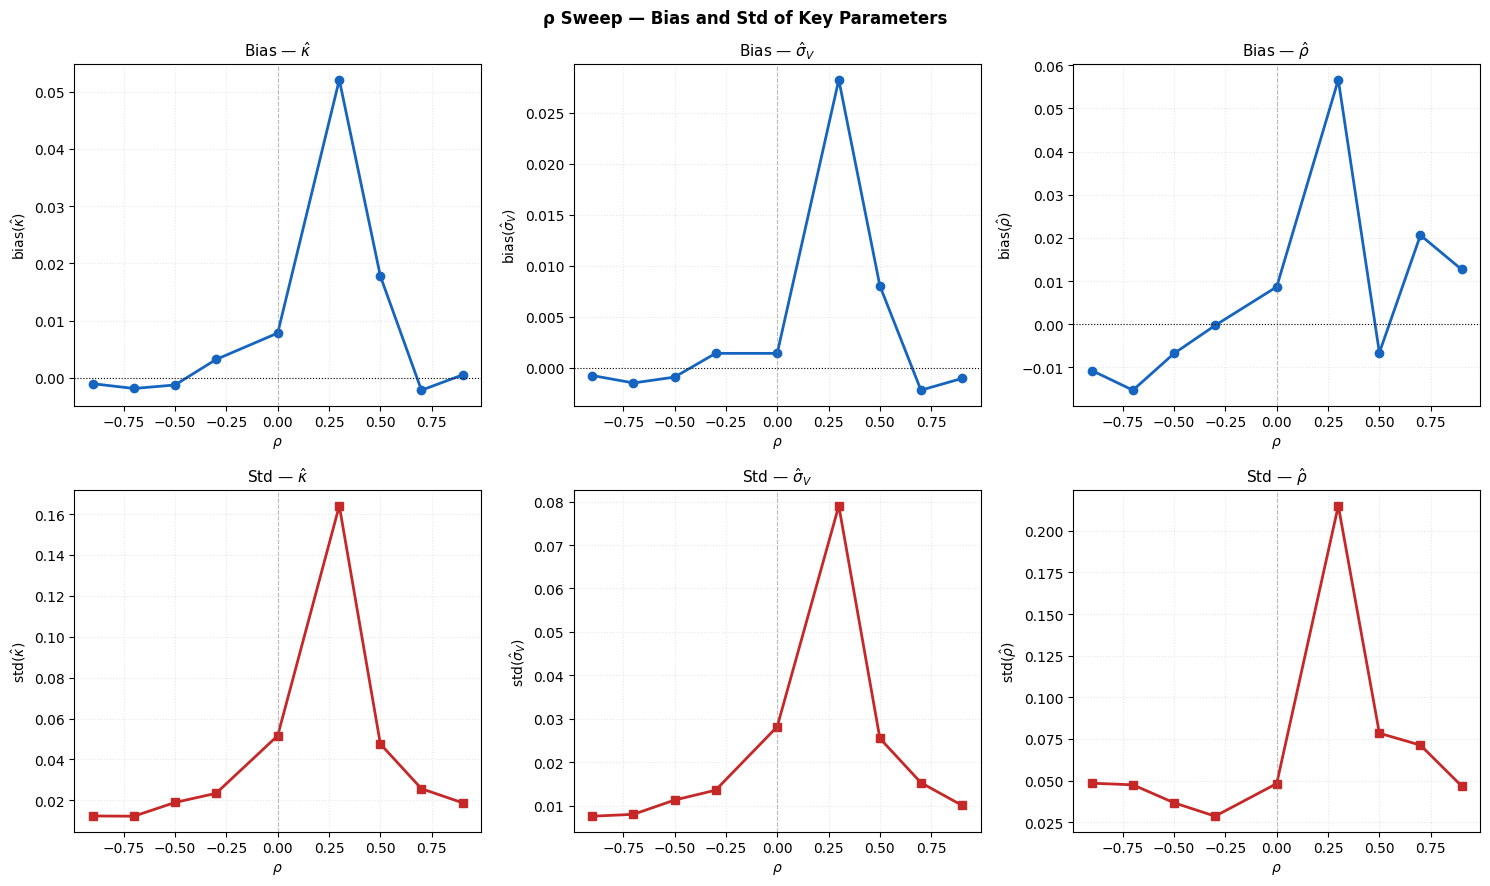

In [12]:
TRUE_base = dict(mu=0.125, kappa=0.1, theta=0.25, sigma_V=0.1, rho=-0.7)

results = experiment_rho_sweep_v2(
    TRUE_base, TRUE_base['theta'],
    h=1.0, n_sub=int(20), n_rep=50, N=int(400_000)
)

In [13]:
def print_rho_latex(results, n_rep, N):
    """Prints filled LaTeX table from results."""

    print(r"\begin{table}[h]")
    print(r"    \centering")
    print(r"    \caption{Bias, standard deviation and RMSE of parameter"
          r" estimates for varying values of $\rho$}")
    print(r"    \label{tab:rho_sweep}")
    print(r"    \begin{threeparttable}")
    print(r"    \begin{tabular}{l ccc ccc ccc}")
    print(r"    \toprule")
    print(r"    & \multicolumn{3}{c}{$\hat\kappa$}"
          r"    & \multicolumn{3}{c}{$\hat\sigma_V$}"
          r"    & \multicolumn{3}{c}{$\hat\rho$} \\")
    print(r"    \cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10}")
    print(r"    $\rho$ & Bias & Std & RMSE"
          r"           & Bias & Std & RMSE"
          r"           & Bias & Std & RMSE \\")
    print(r"    \midrule")

    for r in results:
        rho_str = (f"$\\phantom{{-}}{r['rho']:.1f}$"
                   if r['rho'] >= 0 else f"${r['rho']:.1f}$")

        def fmt(val):
            if not np.isfinite(val):
                return r"\textemdash"
            return f"{val:.4f}"

        row = (f"    {rho_str} "
               f"& {fmt(r['bias_kappa'])} "
               f"& {fmt(r['std_kappa'])} "
               f"& {fmt(r['rmse_kappa'])} "
               f"& {fmt(r['bias_sigma_V'])} "
               f"& {fmt(r['std_sigma_V'])} "
               f"& {fmt(r['rmse_sigma_V'])} "
               f"& {fmt(r['bias_rho'])} "
               f"& {fmt(r['std_rho'])} "
               f"& {fmt(r['rmse_rho'])} \\\\")
        print(row)

    print(r"    \bottomrule")
    print(r"    \end{tabular}")
    print(r"    \begin{tablenotes}")
    print(r"        \small")
    print(r"        \item \textit{Notes:} Based on " + str(n_rep) +
          r" replications of $N = " + f"{N:,}" +
          r"$ observations with $h = 1$ and $n_{\mathrm{sub}} = 20$. "
          r"Baseline parameters: $\mu = 0.125$, $\kappa = 0.1$, "
          r"$\theta = 0.25$, $\sigma_V = 0.1$. "
          r"A dash (\textemdash) indicates all estimates were "
          r"numerically invalid at that $\rho$ value.")
    print(r"    \end{tablenotes}")
    print(r"    \end{threeparttable}")
    print(r"\end{table}")


print_rho_latex(results, n_rep=50, N=400_000)

\begin{table}[h]
    \centering
    \caption{Bias, standard deviation and RMSE of parameter estimates for varying values of $\rho$}
    \label{tab:rho_sweep}
    \begin{threeparttable}
    \begin{tabular}{l ccc ccc ccc}
    \toprule
    & \multicolumn{3}{c}{$\hat\kappa$}    & \multicolumn{3}{c}{$\hat\sigma_V$}    & \multicolumn{3}{c}{$\hat\rho$} \\
    \cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10}
    $\rho$ & Bias & Std & RMSE           & Bias & Std & RMSE           & Bias & Std & RMSE \\
    \midrule
    $-0.9$ & -0.0010 & 0.0124 & 0.0124 & -0.0008 & 0.0076 & 0.0076 & -0.0108 & 0.0484 & 0.0496 \\
    $-0.7$ & -0.0019 & 0.0122 & 0.0124 & -0.0015 & 0.0080 & 0.0081 & -0.0153 & 0.0475 & 0.0499 \\
    $-0.5$ & -0.0013 & 0.0190 & 0.0190 & -0.0009 & 0.0113 & 0.0113 & -0.0068 & 0.0367 & 0.0373 \\
    $-0.3$ & 0.0032 & 0.0235 & 0.0237 & 0.0014 & 0.0136 & 0.0136 & -0.0003 & 0.0286 & 0.0286 \\
    $\phantom{-}0.0$ & 0.0078 & 0.0516 & 0.0522 & 0.0014 & 0.0282 & 0.0282 & 0.0086 & 0.04